<a href="https://colab.research.google.com/github/sukritghosh886-hub/Tower--of-hanoi/blob/main/taxi_app_ml_url.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Install Kaggle API
!pip install kaggle

# Upload your kaggle.json API key
from google.colab import files
files.upload()  # select kaggle.json

# Move to correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset (example with TripFare)
!kaggle datasets download -d ivasanthp/tripfare-predicting-urban-taxi-fare
!unzip tripfare-predicting-urban-taxi-fare.zip

# Load into pandas
import pandas as pd
df = pd.read_csv('taxi_fare.csv')
print(df.head())

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ivasanthp/tripfare-predicting-urban-taxi-fare
License(s): MIT
100% 7.72M/7.72M [00:00<00:00, 89.6MB/s]

Archive:  tripfare-predicting-urban-taxi-fare.zip
  inflating: taxi_fare.csv           
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2016-03-01 00:00:00   2016-03-01 00:07:55                1   
1         1  2016-03-01 00:00:00   2016-03-01 00:11:06                1   
2         2  2016-03-01 00:00:00   2016-03-01 00:31:06                2   
3         2  2016-03-01 00:00:00   2016-03-01 00:00:00                3   
4         2  2016-03-01 00:00:00   2016-03-01 00:00:00                5   

   pickup_longitude  pickup_latitude  RatecodeID store_and_fwd_flag  \
0        -73.976746        40.765152           1                  N   
1        -73.983482        40.767925 

In [ ]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("lilly1739/car-ride-records-dataset")

print("Path to dataset files:", path)

In [ ]:
# ============================================================
#  TAXI RIDE BOOKING APP – WITH FALLBACK LOOP
#  Real Data + Pickup Hour + Re‑matching on Rejection
# ============================================================

!pip install folium -q

import pandas as pd
import numpy as np
import folium
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. USE ALREADY LOADED DATA (FROM taxi_fare.csv)
# ------------------------------------------------------------
df_raw = df.copy()
print(f"✅ Data sourced from local 'df': {df_raw.shape[0]} trips")

# ------------------------------------------------------------
# 2. DATA CLEANING & CALCULATE TRIP DISTANCE
# ------------------------------------------------------------
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Filter for valid coordinate ranges and reasonable fares
df_clean = df_raw[(df_raw['pickup_latitude'] != 0) & (df_raw['pickup_longitude'] != 0) &
                  (df_raw['dropoff_latitude'] != 0) & (df_raw['dropoff_longitude'] != 0)].copy()

# Calculate trip_distance manually since it's missing in this CSV
df_clean['trip_distance'] = df_clean.apply(lambda r: haversine(r['pickup_latitude'], r['pickup_longitude'],
                                                               r['dropoff_latitude'], r['dropoff_longitude']), axis=1)

df_clean['pickup_datetime'] = pd.to_datetime(df_clean['tpep_pickup_datetime'])
df_clean['pickup_hour'] = df_clean['pickup_datetime'].dt.hour

df_clean = df_clean[(df_clean['fare_amount'] >= 2.5) & (df_clean['fare_amount'] <= 100)]
df_clean = df_clean[df_clean['passenger_count'] > 0]

df_sim = df_clean.sample(n=min(500, len(df_clean)), random_state=42).reset_index(drop=True)
print(f"✅ Cleaned dataset: {df_sim.shape[0]} trips")

# ------------------------------------------------------------
# 3. CREATE DRIVERS
# ------------------------------------------------------------
n_drivers = 40
driver_locs = df_sim[['pickup_latitude', 'pickup_longitude']].sample(n=n_drivers, random_state=101).values

np.random.seed(42)
rejection_rates = np.random.beta(2, 10, n_drivers)
high_idx = np.random.choice(n_drivers, size=4, replace=False)
rejection_rates[high_idx] = np.random.uniform(0.91, 0.99, 4)

drivers = pd.DataFrame({
    'driver_id': range(n_drivers),
    'lat': driver_locs[:, 0],
    'lon': driver_locs[:, 1],
    'rejection_rate': rejection_rates,
    'is_blacklisted': rejection_rates > 0.9
})
print(f"🚗 Drivers: {n_drivers} created, {drivers['is_blacklisted'].sum()} initially blacklisted")

# ------------------------------------------------------------
# 4. RIDERS
# ------------------------------------------------------------
riders = pd.DataFrame({
    'rider_id': df_sim.index,
    'lat': df_sim['pickup_latitude'],
    'lon': df_sim['pickup_longitude'],
    'trip_distance': df_sim['trip_distance'],
    'passenger_count': df_sim['passenger_count'],
    'pickup_hour': df_sim['pickup_hour'],
    'actual_fare': df_sim['fare_amount']
})
print(f"👤 Riders (requests): {len(riders)}")

# ------------------------------------------------------------
# 5. MATCHING & FALLBACK LOOP
# ------------------------------------------------------------
def match_nearest_excluding(rider_row, drivers_df, exclude_ids=[]):
    available = drivers_df[(~drivers_df['is_blacklisted']) & (~drivers_df['driver_id'].isin(exclude_ids))].copy()
    if available.empty: return None, None
    available['dist'] = available.apply(lambda row: haversine(rider_row['lat'], rider_row['lon'], row['lat'], row['lon']), axis=1)
    best = available.loc[available['dist'].idxmin()]
    return best['driver_id'], best['dist']

def simulate_acceptance(driver_id):
    driver = drivers[drivers['driver_id'] == driver_id].iloc[0]
    accept = np.random.rand() < (1 - driver['rejection_rate'])
    if not accept:
        new_rate = min(driver['rejection_rate'] + 0.02, 1.0)
        drivers.loc[drivers['driver_id'] == driver_id, 'rejection_rate'] = new_rate
        drivers.loc[drivers['driver_id'] == driver_id, 'is_blacklisted'] = new_rate > 0.9
    return accept

matched_drivers, matched_distances, attempt_counts = [], [], []
for _, rider in riders.iterrows():
    excluded, final_driver, final_dist, attempts = [], None, None, 0
    while True:
        drv_id, dist = match_nearest_excluding(rider, drivers, exclude_ids=excluded)
        if drv_id is None: break
        attempts += 1
        if simulate_acceptance(drv_id):
            final_driver, final_dist = drv_id, dist
            break
        else: excluded.append(drv_id)
    matched_drivers.append(final_driver)
    matched_distances.append(final_dist)
    attempt_counts.append(attempts)

riders['matched_driver'], riders['distance_km'], riders['attempts'] = matched_drivers, matched_distances, attempt_counts
print("\n✅ Matching complete.")

# ------------------------------------------------------------
# 8. TRAIN LINEAR REGRESSION
# ------------------------------------------------------------
features = ['trip_distance', 'passenger_count', 'pickup_hour']
X, y = riders[features].values, riders['actual_fare'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
print(f"\n📊 R²: {r2_score(y_test, model.predict(X_test)):.3f}")

# ------------------------------------------------------------
# 9. LIVE MAP
# ------------------------------------------------------------
center_lat, center_lon = riders['lat'].mean(), riders['lon'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)
for _, d in drivers.iterrows():
    folium.CircleMarker([d['lat'], d['lon']], radius=5, color='red' if d['is_blacklisted'] else 'green', fill=True).add_to(m)
display(m)

✅ Data sourced from local 'df': 212345 trips
✅ Cleaned dataset: 500 trips
🚗 Drivers: 40 created, 4 initially blacklisted
👤 Riders (requests): 500

✅ Matching complete.

📊 R²: 0.886


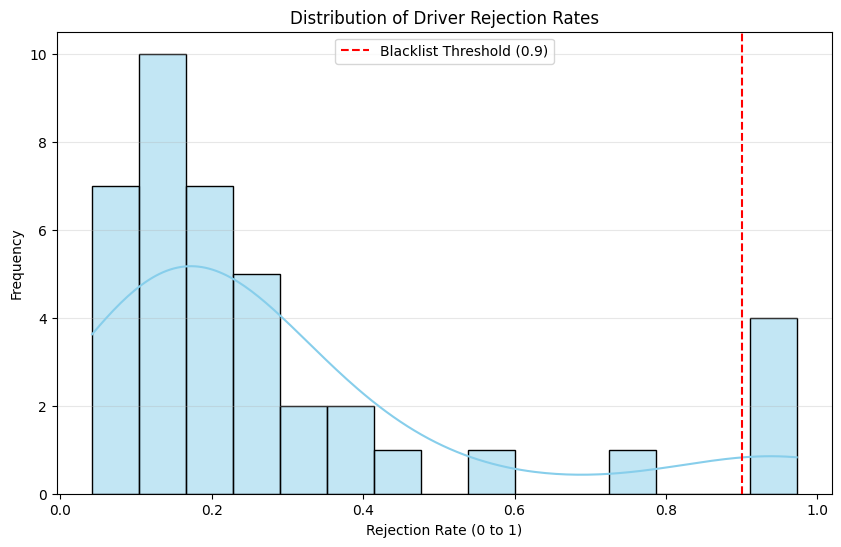

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(drivers['rejection_rate'], bins=15, kde=True, color='skyblue')

plt.title('Distribution of Driver Rejection Rates')
plt.xlabel('Rejection Rate (0 to 1)')
plt.ylabel('Frequency')
plt.axvline(0.9, color='red', linestyle='--', label='Blacklist Threshold (0.9)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

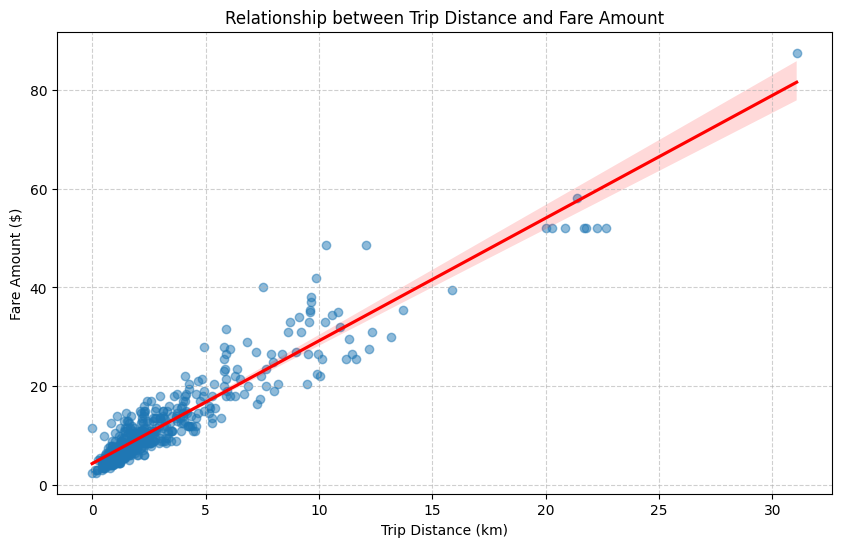

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(data=riders, x='trip_distance', y='actual_fare', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relationship between Trip Distance and Fare Amount')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import folium
from math import radians, sin, cos, sqrt, atan2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# STEP 1: Load local data instead of the broken URL
print("=" * 60)
print("STEP 1: Loading local taxi data")
print("=" * 60)

# Using the dataframe 'df' already loaded in your notebook
df_raw = df.copy()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

# Filter for valid NYC coordinates
df = df_raw[(df_raw['pickup_latitude'].between(40.5, 40.9)) &
            (df_raw['pickup_longitude'].between(-74.05, -73.7))].copy()

# Calculate trip_distance manually if needed or use existing
if 'trip_distance' not in df.columns:
    df['trip_distance'] = df.apply(lambda r: haversine(r['pickup_latitude'], r['pickup_longitude'], r['dropoff_latitude'], r['dropoff_longitude']), axis=1)

df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_hour'] = df['pickup_datetime'].dt.hour

# Clean outliers
df = df[(df['fare_amount'] >= 2.5) & (df['fare_amount'] <= 100)]
df = df[df['passenger_count'] > 0]
df = df.sample(n=min(500, len(df)), random_state=42).reset_index(drop=True)

print(f"Cleaned data shape: {df.shape}")

# --- Rest of the simulation remains the same ---
N_DRIVERS = 40
driver_locs = df[['pickup_latitude', 'pickup_longitude']].sample(n=N_DRIVERS, random_state=101).values
rejection_rates = np.random.beta(2, 10, N_DRIVERS)
high_rej_idx = np.random.choice(N_DRIVERS, size=4, replace=False)
rejection_rates[high_rej_idx] = np.random.uniform(0.91, 0.99, 4)

drivers = pd.DataFrame({'driver_id': range(N_DRIVERS), 'lat': driver_locs[:, 0], 'lon': driver_locs[:, 1], 'rejection_rate': rejection_rates, 'is_blacklisted': rejection_rates > 0.9})

riders = pd.DataFrame({'rider_id': df.index, 'lat': df['pickup_latitude'], 'lon': df['pickup_longitude'], 'trip_distance': df['trip_distance'], 'passenger_count': df['passenger_count'], 'pickup_hour': df['pickup_hour'], 'actual_fare': df['fare_amount']})

def find_nearest_excluding(rider_row, drivers_df, exclude_ids):
    available = drivers_df[(~drivers_df['is_blacklisted']) & (~drivers_df['driver_id'].isin(exclude_ids))].copy()
    if available.empty: return None, None
    available['dist'] = available.apply(lambda row: haversine(rider_row['lat'], rider_row['lon'], row['lat'], row['lon']), axis=1)
    best = available.loc[available['dist'].idxmin()]
    return best['driver_id'], best['dist']

def simulate_acceptance(driver_id):
    driver = drivers[drivers['driver_id'] == driver_id].iloc[0]
    accept = np.random.rand() < (1 - driver['rejection_rate'])
    if not accept:
        new_rate = min(driver['rejection_rate'] + 0.02, 1.0)
        drivers.loc[drivers['driver_id'] == driver_id, 'rejection_rate'] = new_rate
        drivers.loc[drivers['driver_id'] == driver_id, 'is_blacklisted'] = new_rate > 0.9
    return accept

matched_drivers, matched_distances, attempt_counts = [], [], []
for _, rider in riders.iterrows():
    excluded, final_driver, final_dist, attempts = [], None, None, 0
    while True:
        drv_id, dist = find_nearest_excluding(rider, drivers, excluded)
        if drv_id is None: break
        attempts += 1
        if simulate_acceptance(drv_id): final_driver, final_dist = drv_id, dist; break
        else: excluded.append(drv_id)
    matched_drivers.append(final_driver); matched_distances.append(final_dist); attempt_counts.append(attempts)

riders['matched_driver'], riders['distance_km'], riders['attempts'] = matched_drivers, matched_distances, attempt_counts

# STEP 5: Regression
X = riders[['trip_distance', 'passenger_count', 'pickup_hour']].values
y = riders['actual_fare'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
print(f"Model R2: {r2_score(y_test, model.predict(X_test)):.3f}")

# STEP 6: Map
center_lat, center_lon = riders['lat'].mean(), riders['lon'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)
for _, d in drivers.iterrows():
    folium.CircleMarker([d['lat'], d['lon']], radius=6, color='red' if d['is_blacklisted'] else 'green', fill=True).add_to(m)
display(m)

STEP 1: Loading local taxi data
Cleaned data shape: (500, 21)
Model R2: 0.883


In [ ]:
# ====================================================================
#  ONE-CELL ML PIPELINE + 2 APP URLs (Rider & Driver)
#  Uses localtunnel – no sign-up, no token required
# ====================================================================

!pip install flask -q

import pandas as pd
import numpy as np
from flask import Flask, request, render_template_string
import threading
import time
import random
import subprocess
import re
import os
from math import radians, sin, cos, sqrt, atan2
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# --- FIX: Kill any process on ports 5000 or 5001 ---
print("🧹 Cleaning up existing processes...")
subprocess.run("fuser -k 5000/tcp", shell=True, stderr=subprocess.DEVNULL)
subprocess.run("fuser -k 5001/tcp", shell=True, stderr=subprocess.DEVNULL)
time.sleep(2)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# ------------------------------------------------------------
# 1. TRAIN ML MODEL (real NYC taxi data)
# ------------------------------------------------------------
print("🚀 Training ML model...")

df_raw = df_check.copy()
df_raw['pickup_datetime'] = pd.to_datetime(df_raw['tpep_pickup_datetime'])
df_raw['trip_distance_calc'] = df_raw.apply(
    lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'],
                          row['dropoff_latitude'], row['dropoff_longitude']),
    axis=1
)

df_clean = df_raw[['pickup_latitude', 'pickup_longitude', 'fare_amount',
                 'trip_distance_calc', 'passenger_count', 'pickup_datetime']].copy()
df_clean.rename(columns={'trip_distance_calc': 'trip_distance'}, inplace=True)
df_clean['pickup_hour'] = df_clean['pickup_datetime'].dt.hour
df_clean.dropna(inplace=True)

df_clean = df_clean[(df_clean['pickup_latitude'].between(40.6, 40.9)) & (df_clean['pickup_longitude'].between(-74.05, -73.9))]
df_clean = df_clean[(df_clean['fare_amount'] >= 2.5) & (df_clean['fare_amount'] <= 100)]
df_sample = df_clean.sample(n=min(500, len(df_clean)), random_state=42).reset_index(drop=True)

X = df_sample[['trip_distance', 'passenger_count', 'pickup_hour']].values
y = df_sample['fare_amount'].values
model = LinearRegression()
model.fit(X, y)
print("✅ Model trained.")

# ------------------------------------------------------------
# 2. DRIVER SIMULATION
# ------------------------------------------------------------
N_DRIVERS = 20
driver_locs = df_sample[['pickup_latitude', 'pickup_longitude']].sample(n=N_DRIVERS, random_state=101).values
drivers_db = pd.DataFrame({
    'driver_id': range(N_DRIVERS),
    'lat': driver_locs[:, 0],
    'lon': driver_locs[:, 1],
    'rejection_rate': np.random.beta(2, 10, N_DRIVERS),
    'is_blacklisted': False,
    'online': True
})

def find_nearest(rider_lat, rider_lon, exclude=[]):
    available = drivers_db[(drivers_db['online']) & (~drivers_db['is_blacklisted']) & (~drivers_db['driver_id'].isin(exclude))].copy()
    if available.empty: return None, None
    available['dist'] = available.apply(lambda row: haversine(rider_lat, rider_lon, row['lat'], row['lon']), axis=1)
    best = available.loc[available['dist'].idxmin()]
    return int(best['driver_id']), best['dist']

# ------------------------------------------------------------
# 3. FLASK APP
# ------------------------------------------------------------
app = Flask(__name__)
pending_request = None

@app.route('/rider')
def rider_app():
    return render_template_string("""<html><body><h2>✅ Request a Ride</h2><form method='POST' action='/rider/request'>Lat: <input name='lat' value='40.71'><br>Lon: <input name='lon' value='-74.01'><br>Pax: <input name='pax' value='1'><br><input type='submit' value='Request'></form><pre>{{ result }}</pre></body></html>""", result="Ready")

@app.route('/rider/request', methods=['POST'])
def request_ride():
    global pending_request
    lat, lon, pax = float(request.form['lat']), float(request.form['lon']), int(request.form['pax'])
    dist = random.uniform(1, 10)
    fare = model.predict([[dist, pax, 12]])[0]
    drv_id, d = find_nearest(lat, lon)
    if drv_id is not None:
        pending_request = {'rider_lat': lat, 'rider_lon': lon, 'fare': fare, 'driver_id': drv_id}
        return f"Matched with Driver {drv_id}! Est Fare: ${fare:.2f}"
    return "No drivers available."

@app.route('/driver')
def driver_app():
    drv_id = int(request.args.get('driver_id', 0))
    ping = "No requests."
    if pending_request and pending_request['driver_id'] == drv_id:
        ping = f"Incoming! Fare: ${pending_request['fare']:.2f}"
    return f"Driver {drv_id} Panel: {ping}"

def run_app():
    app.run(port=5001, use_reloader=False)

threading.Thread(target=run_app, daemon=True).start()
time.sleep(2)

# ------------------------------------------------------------
# 4. TUNNEL
# ------------------------------------------------------------
print("\n🔗 Creating public tunnel...")
proc = subprocess.Popen(["npx", "localtunnel", "--port", "5001"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
public_url = None
for _ in range(25):
    line = proc.stdout.readline()
    if not line: break
    match = re.search(r"https://[a-z0-9-]+\.loca\.lt", line)
    if match:
        public_url = match.group(0)
        break

if public_url:
    print(f"\n📱 RIDER APP: {public_url}/rider")
    print(f"🚗 DRIVER APP: {public_url}/driver?driver_id=0")
else:
    print("Tunnel failed. Ensure npx localtunnel is installed.")

try:
    while True: time.sleep(10)
except KeyboardInterrupt:
    proc.terminate()

 Training ML model...
✅ Model trained.
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.



 Creating public tunnel...

 RIDER APP: https://salty-cows-cheer.loca.lt/rider

 DRIVER APP: https://salty-cows-cheer.loca.lt/driver?driver_id=0


ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.
ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 5